## Proof of concept for ACTAR TPC event classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
from matplotlib.path import Path
from matplotlib.patches import PathPatch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import uproot
import awkward as ak
from tqdm import tqdm
import ROOT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Read the data

In [2]:
file = uproot.open("./Inputs/simple_tree.root")
tree = file["SimpleTree"]
data = tree.arrays()  # type: ignore

In [3]:
data[0]

<Record {X: [33, ..., 61], Y: [...], ...} type='{X: var * int32, Y: var * i...'>

Build a class inheriting from `torch.Dataset` to load data efficiently

In [4]:
class ACTARDataset(Dataset):
    def __init__(self, data, rebin_factor: int = 1) -> None:
        super().__init__()
        self.data = data
        self.extents = (128, 128)
        self.rebin_factor = rebin_factor
        self.nevents = len(self.data)
        return

    def __len__(self):
        return self.nevents

    def __getitem__(self, idx):
        X = ak.to_numpy(self.data.X[idx])
        Y = ak.to_numpy(self.data.Y[idx])
        Q = ak.to_numpy(self.data.Q[idx])

        img, _, _ = np.histogram2d(
            x=X,
            y=Y,
            bins=[
                self.extents[0] // self.rebin_factor,
                self.extents[1] // self.rebin_factor,
            ],
            range=[[0, self.extents[0]], [0, self.extents[1]]],
            weights=Q,
        )
        # Traspose and reduce float type to 32bits
        img = img.T.astype(np.float32)
        # Normalise
        if img.max() > 0:
            img /= img.max()
        # Binarise
        img = (img > 0).astype(np.float32)

        # Convert to torch tensor and add an extra dimension
        img = torch.from_numpy(img).unsqueeze(0)

        # Return extra information
        info = {"run": self.data.fRun[idx], "entry": self.data.fEntry[idx]}
        return img, info


dataset = ACTARDataset(data, rebin_factor=1)
# Split into train and test
train, test = random_split(
    dataset, lengths=[0.8, 0.2], generator=torch.Generator().manual_seed(42)
)
batch_size = 32
train_loader = DataLoader(train, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=False, num_workers=6)
train_imgs, train_infos = next(iter(train_loader))

Test datasets and dataloader work

In [5]:
train_imgs[0].shape

torch.Size([1, 128, 128])

Define helper function to plot events

In [6]:
def plot_event(ev, ax=None, thresh: float = 0, **kwargs):
    img = ev.squeeze()
    img[img <= thresh] = np.nan
    ax = ax if ax is not None else plt.gca()
    opts = {"cmap": "managua_r", **kwargs}
    ax.pcolormesh(img, **opts)

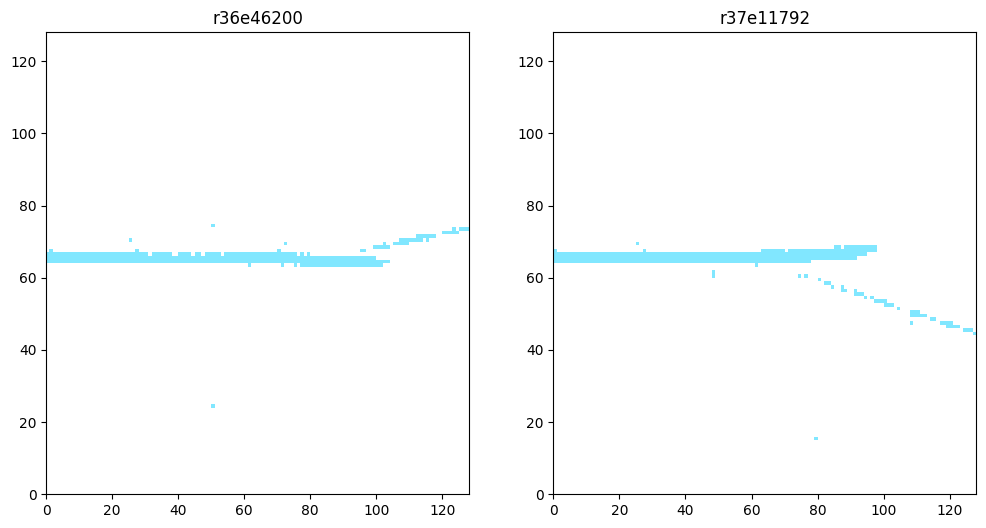

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
for i, ax in enumerate(axs):
    plot_event(train_imgs[i], ax=ax, cmap="managua_r")
    r = train_infos["run"][i]
    e = train_infos["entry"][i]
    ax.set_title(f"r{r}e{e}")

### Define the model

In [8]:
class Autoencoder(nn.Module):
    def __init__(self, in_dim=(128, 128), latent_dim: int = 16) -> None:
        super().__init__()
        self.in_dim = in_dim
        self.latent_dim: int = latent_dim
        ## Apply a reduction factor
        # 4 arises from stride1 = 2 and stride2 = 2 -> /2 /2 dim reduction
        self.reduced_dim = (self.in_dim[0] // 4, self.in_dim[1] // 4)

        # Encoder
        self.encoder: nn.Sequential = nn.Sequential(
            nn.Conv2d(
                in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * self.reduced_dim[0] * self.reduced_dim[1], self.latent_dim),
        )

        # Decoder
        self.decoder: nn.Sequential = nn.Sequential(
            nn.Linear(self.latent_dim, 32 * self.reduced_dim[0] * self.reduced_dim[1]),
            nn.ReLU(),
            nn.Unflatten(1, (32, self.reduced_dim[0], self.reduced_dim[1])),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )
        return

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z


model = Autoencoder(latent_dim=16).to(device)


# Mean squared error
def weighted_mse(rec, target, weight=100.0):
    weights = torch.where(target > 0, weight, 1.0)
    return (weights * (rec - target) ** 2).mean()

# Dice loss
def dice_loss(rec, target, eps=1e-6):
    rec_flat = rec.view(rec.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    inter = (rec_flat * target_flat).sum(dim=1)
    union = rec_flat.sum(dim=1) + target_flat.sum(dim=1)
    dice = (2 * inter + eps) / (union + eps)
    return 1 - dice.mean()

# Combine both
def combined_loss(rec, target, w_mse=1.0, w_dice=2.0):
    mse = weighted_mse(rec, target, weight=100.0)
    dice = dice_loss(rec, target)
    return w_mse * mse + w_dice * dice


# Optimiser
optimiser = optim.Adam(model.parameters(), lr=1e-3)

And now train!

In [9]:
n_epochs = 20

history = {"train_loss": []}

for epoch in range(n_epochs):
    model.train()
    total_loss = 0

    # loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for images, infos in train_loader:
        images = images.to(device)
        rec, _ = model(images)
        # loss = weighted_mse(rec, images)
        # loss = combined_loss(rec, images)
        loss = nn.functional.binary_cross_entropy(rec, images)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
        # loop.set_postfix(loss=loss.item())

    train_loss = total_loss / len(train_loader)
    history["train_loss"].append(train_loss)
    print(f"Epoch {epoch+1}: train={train_loss:.5f}")

Epoch 1: train=0.11268
Epoch 2: train=0.03679
Epoch 3: train=0.02404
Epoch 4: train=0.01835
Epoch 5: train=0.01569
Epoch 6: train=0.01418
Epoch 7: train=0.01318
Epoch 8: train=0.01242
Epoch 9: train=0.01183
Epoch 10: train=0.01132
Epoch 11: train=0.01087
Epoch 12: train=0.01052
Epoch 13: train=0.01022
Epoch 14: train=0.00993
Epoch 15: train=0.00964
Epoch 16: train=0.00937
Epoch 17: train=0.00914
Epoch 18: train=0.00891
Epoch 19: train=0.00874
Epoch 20: train=0.00860


Text(0, 0.5, 'loss')

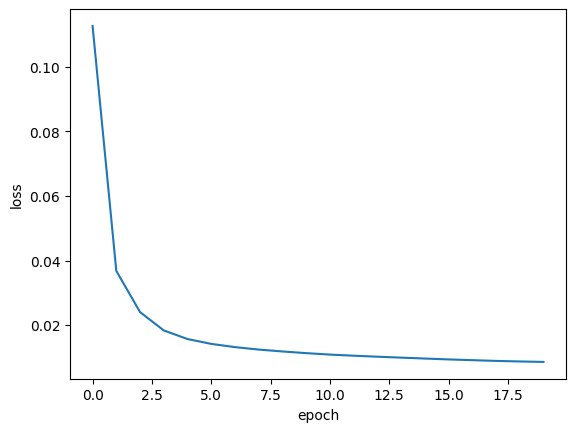

In [10]:
plt.plot(history["train_loss"])
plt.xlabel("epoch")
plt.ylabel("loss")

Get the latent space and do PCA

In [11]:
model.eval()
latents = []
with torch.no_grad():
    for images, infos in test_loader:
        images = images.to(device)
        _, latent = model(images)
        latents.append(latent.cpu().numpy())
latents = np.concatenate(latents)
print(latents.shape)

(1293, 16)


PCA after std normalisation

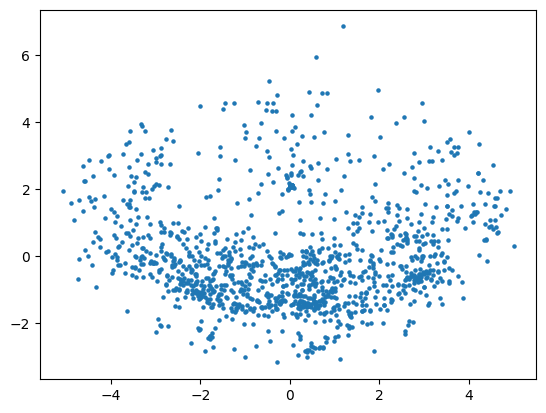

In [12]:
latents_scaled = StandardScaler().fit_transform(latents) #type:ignore
pca = PCA(n_components=2)
latents_2d = pca.fit_transform(latents_scaled)

fig, ax = plt.subplots()
ax.scatter(latents_2d[:, 0], latents_2d[:, 1], s=5)

### Print original against reconstructed

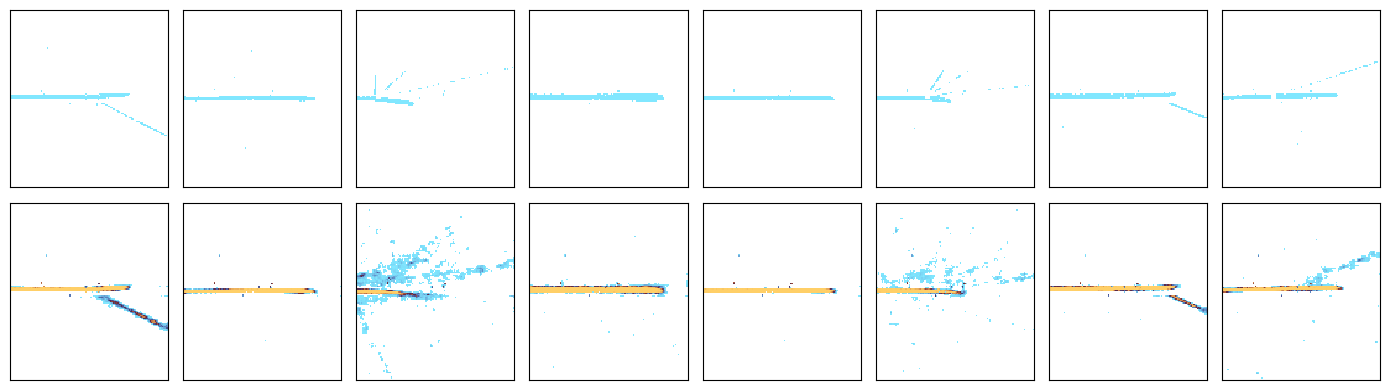

In [56]:
model.eval()
images, infos = next(iter(test_loader))
with torch.no_grad():
    rec, _ = model(images)

fig, axs = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    # Original
    ax = axs[0, i]
    plot_event(images[i], ax=ax)
    # Rec
    ax = axs[1, i]
    plot_event(rec[i], ax=ax, thresh=1e-2)
# Settings
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

## Debug the two regions
### Central region

In [16]:
%matplotlib tk
fig, ax = plt.subplots()
ax.scatter(latents_2d[:, 0], latents_2d[:, 1], s=5)
fig.show()

selector = PolygonSelector(ax)

In [17]:
central = Path(selector.verts, closed=True)

In [18]:
latents_idxs = np.arange(len(latents_2d))
inside_central = central.contains_points(latents_2d)
central_idxs = latents_idxs[inside_central]

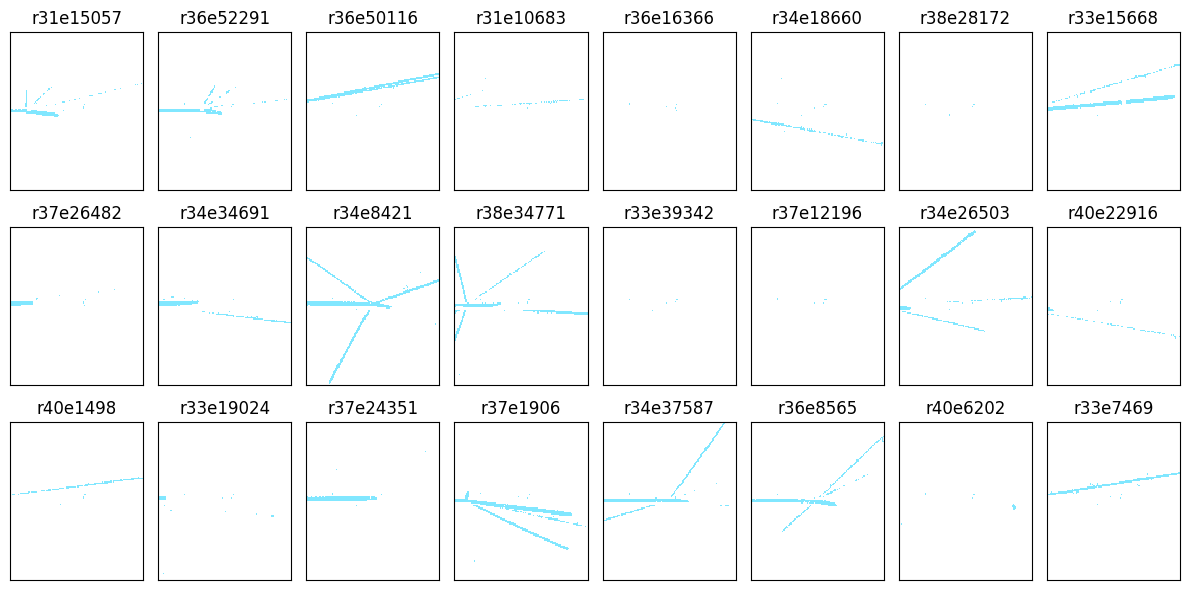

In [19]:
%matplotlib inline
fig, axs = plt.subplots(3, 8, figsize=(12,6))
for i, ax in enumerate(axs.flat):
    img, info = test[central_idxs[i]] #type: ignore
    plot_event(img, ax=ax)
    ax.set_title(f"r{info['run']}e{info['entry']}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

### Arc region

In [28]:
%matplotlib tk
fig, ax = plt.subplots()
ax.scatter(latents_2d[:, 0], latents_2d[:, 1], s=5)
fig.show()

sel1 = PolygonSelector(ax)


In [29]:
arc = Path(sel1.verts, closed=True)

In [30]:
inside_arc = arc.contains_points(latents_2d)
arc_idxs = latents_idxs[inside_arc]
len(arc_idxs)

604

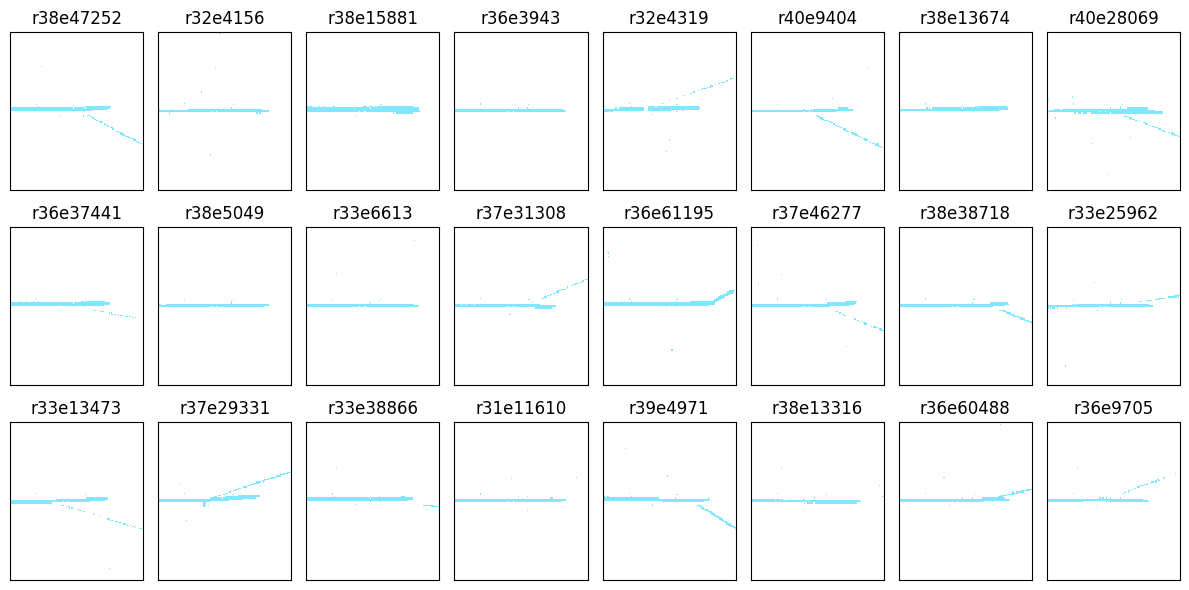

In [31]:
%matplotlib inline
fig, axs = plt.subplots(3, 8, figsize=(12,6))
for i, ax in enumerate(axs.flat):
    img, info = test[arc_idxs[i]] #type: ignore
    plot_event(img, ax=ax)
    ax.set_title(f"r{info['run']}e{info['entry']}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

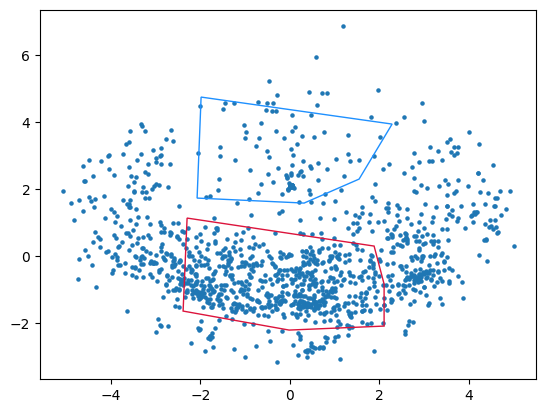

In [32]:
fig, ax = plt.subplots()
ax.scatter(latents_2d[:, 0], latents_2d[:, 1], s=5)
cut0 = PathPatch(central, ec="dodgerblue", fc="none")
cut1 = PathPatch(arc, ec="crimson", fc="none")
ax.add_patch(cut0)
ax.add_patch(cut1)


## Alternative: compare binary cross-entropy between rec and target

In [37]:
bce = nn.BCELoss(reduction="none")

bces = []

model.eval()
with torch.no_grad():
    for images, infos in test_loader:
        rec, _ = model(images)
        loss = bce(rec, images)
        loss = loss.mean(dim=[1, 2, 3])
        bces.append(loss.cpu().numpy())

bces = np.concatenate(bces)
print(bces.shape)

(1293,)


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7fa972ec6e00>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

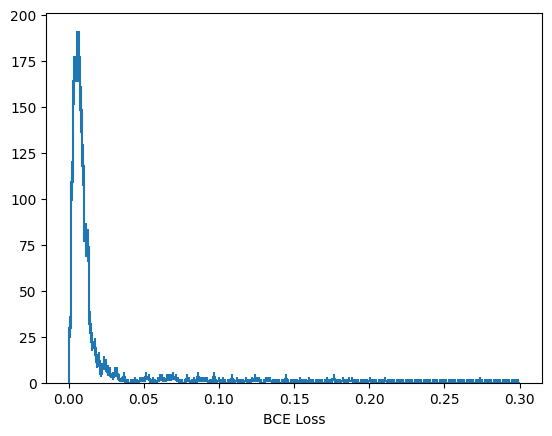

In [43]:
import hist

h = hist.Hist.new.Reg(200, 0, 0.3, label="BCE Loss").Double()
h.fill(bces)

h.plot()

In [52]:
np.histogram(rec[0].flatten())

(array([15971,    16,     8,    13,    11,    12,     6,    13,    11,
          323]),
 array([1.6946590e-14, 1.0000000e-01, 2.0000000e-01, 3.0000001e-01,
        4.0000001e-01, 5.0000000e-01, 6.0000002e-01, 6.9999999e-01,
        8.0000001e-01, 9.0000004e-01, 1.0000000e+00], dtype=float32))